In [1]:
import pandas as pd
from datetime import datetime
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as ss
from scipy.stats import norm
from tqdm.auto import tqdm

In [30]:
#Загружаем исходные данные
reg=pd.read_csv("C:/Users/Ksenya/Downloads/problem1-reg_data.csv", sep=';')
auth=pd.read_csv("C:/Users/Ksenya/Downloads/problem1-auth_data.csv", sep=";")

In [31]:
#Смотрим формат данных
reg.head()

,reg_ts,uid
0,911382223,1
1,932683089,2
2,947802447,3
3,959523541,4
4,969103313,5


In [32]:
auth.head()

,auth_ts,uid
0,911382223,1
1,932683089,2
2,932921206,2
3,933393015,2
4,933875379,2


In [33]:
#Проверяем типы данных
reg.dtypes

reg_ts    int64
uid       int64
dtype: object

In [34]:
auth.dtypes

auth_ts    int64
uid        int64
dtype: object

In [35]:
#проверяем данные на наличие дубликатов
reg[reg.duplicated ()]

,reg_ts,uid


In [36]:
auth[auth.duplicated ()]

,auth_ts,uid


In [38]:
#Добавим столбцы с датой, приведя их в обычный формат
reg['date_reg']=pd.to_datetime(reg['reg_ts'], unit='s').dt.round('d') 
auth['date_auth']=pd.to_datetime(auth['auth_ts'], unit='s').dt.round('d') 

In [43]:
#Пишем функцию, передаем в неё 3 параметра, первый задает дату начала периода, 2-ой дату конца периода и 3-ий по какому дню считаем retention
def retention(start_reg_date, end_reg_date, end_auth_date):
    #Берем только те данные для анализа, которые не противоречат аргументам функции
    df_reg = reg.query('date_reg  >= @start_reg_date and date_reg  < @end_reg_date')
    # Выбираем последнюю дату захода
    df_auth = (auth.query('date_auth  < @end_auth_date'))
    #Объединяем таблицы с выбранными значениями
    full_df = df_reg.merge(df_auth, how = 'left', on ='uid') 
    # Вычисляем разницу между датой захода и регистрацией в днях
    full_df['date_dif'] = (full_df.date_auth - full_df.date_reg).dt.days
    # Создаем когорты
    cohort = full_df.groupby(['date_reg', 'date_dif']) \
               .agg({'uid' : 'nunique'}) \
               .reset_index()
    cohort = cohort.rename(columns={'date_reg': 'cohort', 'date_dif': 'cohort_period'})
    cohort.reset_index()
    cohort.set_index(['cohort'], inplace=True)
    cohort['cohort_size'] = cohort.groupby('cohort')['uid'].max()
    # Считаем ретеншен
    cohort['retention'] = cohort.uid / cohort.cohort_size
    # Транспонируем таблицу
    cohort.reset_index(inplace=True)
    cohort = cohort.pivot(index='cohort', columns='cohort_period', values='retention')
    # Визуализируем таблицу
    plt.figure(figsize=(15, 10))
    plt.title('Retention')
    ax = sns.heatmap(data=cohort, annot=True, annot_kws = {'size':16}, cmap="BuPu", vmin=0.0, vmax=0.1)
    ax.set_title('Retention', fontdict={'fontsize':18}, pad=14)
    ax.set_yticklabels(cohort.index.strftime('%Y-%m-%d'), fontsize = 18)
    ax.set_xticklabels(cohort.columns, fontsize = 18)
    fig=ax.get_figure()
    plt.show() 

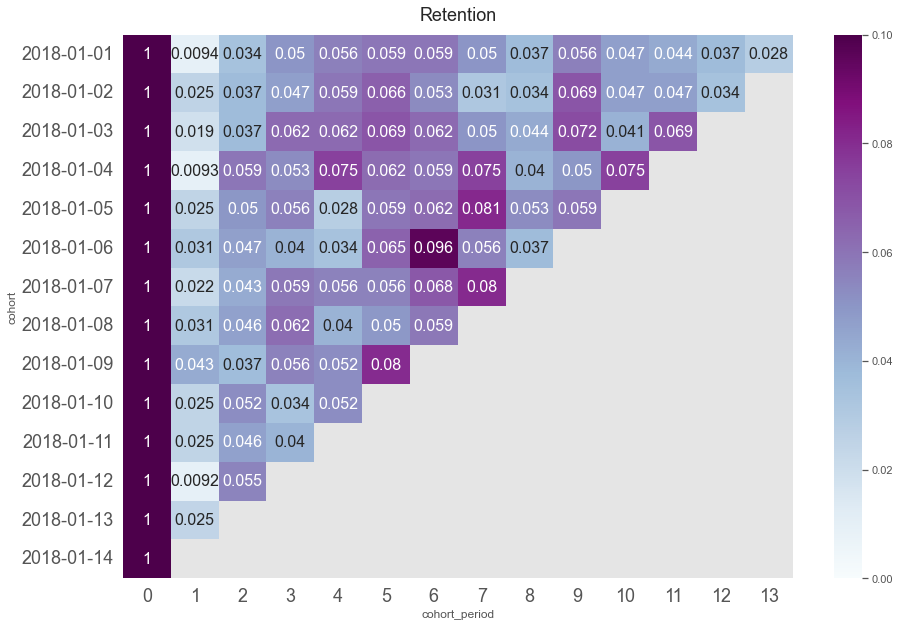

In [44]:
retention('2018-1-1', '2018-1-15', '2018-1-15')

# Задание 2

In [18]:
dataset=pd.read_csv("C:/Users/Ksenya/Downloads/Проект_1_Задание_2.csv", sep=";")

In [19]:
# посмотрим базовую статистику по нашим данным
dataset.groupby('testgroup').revenue.describe()

,count,mean,std,min,25%,50%,75%,max
testgroup,,,,,,,,
a,202103.0,25.413720,920.768137,0.0,0.0,0.0,0.0,37433.0
b,202667.0,26.751287,287.324162,0.0,0.0,0.0,0.0,4000.0


In [20]:
# Посмотрим метрики для обоих групп но только для платящих пользователей
dataset.query('revenue >0').groupby('testgroup').revenue.describe()

,count,mean,std,min,25%,50%,75%,max
testgroup,,,,,,,,
a,1928.0,2663.998444,9049.039763,200.0,257.0,311.0,361.0,37433.0
b,1805.0,3003.658172,572.619709,2000.0,2513.0,3022.0,3478.0,4000.0


In [21]:
#Разделим датасет на тестовую и контрольную группу, для удобства
testgroup_a = dataset.query('testgroup == "a"')
testgroup_b = dataset.query('testgroup == "b"')

In [22]:
#Проверим распеределения на нормальность, с помощью теста Шапиро-Уилка, среди платящих пользователей
ss.shapiro(testgroup_a.query('revenue > 0').revenue)

ShapiroResult(statistic=0.26679253578186035, pvalue=0.0)

In [23]:
#Можем видеть,что в обоих вариантах распределение не нормальное, так как p-value<0,05
ss.shapiro(testgroup_b.query('revenue > 0').revenue)

ShapiroResult(statistic=0.9583123922348022, pvalue=2.491345674771425e-22)

<AxesSubplot:xlabel='revenue', ylabel='testgroup'>

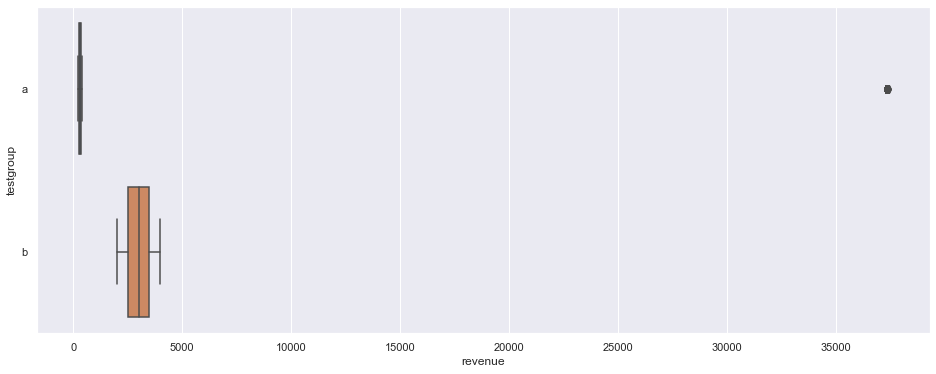

In [24]:
#Построим для наглядности график боксплот, чтоб увидеть возможные выбросы
sns.set(rc={'figure.figsize':(16,6)})
sns.boxplot(data=dataset.query('revenue !=0'), y='testgroup', x='revenue')

In [25]:
#Посчитаем количество ползователей, из-за которых наблюдается выброс
dataset.query('revenue > 30000').revenue.count()

123

In [26]:
#Используем метод бутстрап среди пользователей revenue>0
# Объявим функцию, которая позволит проверять гипотезы с помощью бутстрапа
def get_bootstrap(
    data_column_1, # числовые значения первой выборки
    data_column_2, # числовые значения второй выборки
    boot_it = 1000, # количество бутстрэп-подвыборок
    statistic = np.mean, # интересующая нас статистика
    bootstrap_conf_level = 0.95 # уровень значимости
):
    boot_len = max([len(data_column_1), len(data_column_2)])
    boot_data = []
    for i in tqdm(range(boot_it)): # извлекаем подвыборки
        samples_1 = data_column_1.sample(
            boot_len, 
            replace = True # параметр возвращения
        ).values
        
        samples_2 = data_column_2.sample(
            boot_len, 
            replace = True
        ).values
        
        boot_data.append(statistic(samples_1-samples_2)) # mean() - применяем статистику
        
    pd_boot_data = pd.DataFrame(boot_data)
        
    left_quant = (1 - bootstrap_conf_level)/2
    right_quant = 1 - (1 - bootstrap_conf_level) / 2
    ci = pd_boot_data.quantile([left_quant, right_quant])
        
    p_1 = norm.cdf(
        x = 0, 
        loc = np.mean(boot_data), 
        scale = np.std(boot_data)
    )
    p_2 = norm.cdf(
        x = 0, 
        loc = -np.mean(boot_data), 
        scale = np.std(boot_data)
    )
    p_value = min(p_1, p_2) * 2
        
    # Визуализация
    plt.hist(pd_boot_data[0], bins = 50)
    
    plt.style.use('ggplot')
    plt.vlines(ci,ymin=0,ymax=50,linestyle='--')
    plt.xlabel('boot_data')
    plt.ylabel('frequency')
    plt.title("Histogram of boot_data")
    plt.show()
       
    return {"boot_data": boot_data, 
            "ci": ci, 
            "p_value": p_value}

  0%|          | 0/2000 [00:00<?, ?it/s]

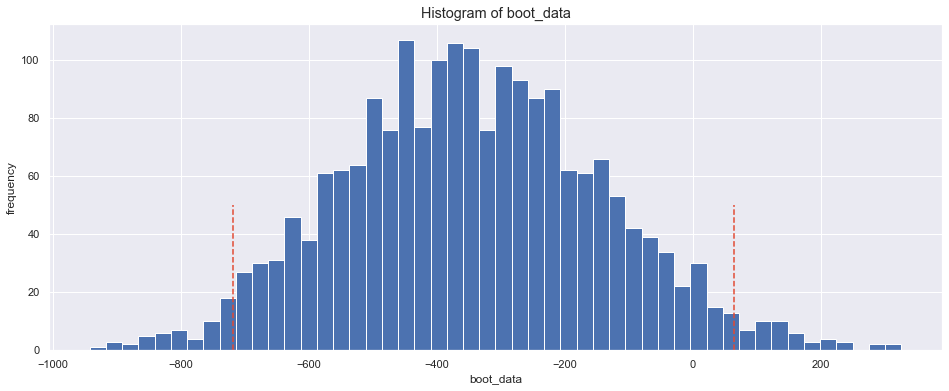

In [27]:
#bootstrap с np.mean
booted_data_mean = get_bootstrap(testgroup_a.query('revenue > 0').revenue, testgroup_b.query('revenue > 0').revenue, boot_it = 2000, statistic = np.mean)

In [28]:
# p-value
booted_data_mean['p_value']

0.09014280804984683

In [29]:
# interval
booted_data_mean['ci']

,0
0.025,-719.405757
0.975,64.194295


Поскольку p_value>0,05 и 0 входит в доверительный интервал, значит статистической разницы между контрольной и тестовой группой нет.

#### Вывод: 

На основании проведенного анализа, мы не видим статистически значимых различий между контрольной и тестовой группами. В контрольной группе имеется выброс в 123 пользователя, они оказывают значительное влияние на средний чек. Возможно эти данные попали в выборку ошибочно, поэтому здесь нельзя окончательно сделать вывод об успешности акционных предложений, сперва нужно перепроверить данные. Если данные попали в выборку не случайно, то набор предложений в тестовой группе является более надежным и стабильным способом получения прибыли.